<a href="https://colab.research.google.com/github/GoudoMahan/AI-agent-practice/blob/main/lab1_task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task1：图表生成

实验中有多处鼓励你修改代码，例如调整提示词、更换不同的大模型，或添加新的查询。欢迎动手尝试，观察修改对工作流行为的影响。

姓名：胡豪达

学号：523021910471

---

## 0. 环境准备（从 GitHub 获取项目）

请先执行下面的代码块克隆仓库：

- **`!git clone`**：克隆远程仓库到本地
- 克隆后需要进入项目目录，才能正确找到 `coffee_sales.csv`、`utils_openrouter.py` 等文件

In [ ]:
!git clone -b Lab1 https://github.com/LxRoboticsLab/AI1112-lab-assets.git
%cd AI1112-lab-assets

# 安装依赖
!pip install pandas matplotlib requests python-dotenv

import os
import base64

encoded_key = "c2stb3ItdjEtOTZlNzczMTQ5Y2YxODVkYzQ3ZGFiZmY3YzA0ODc4NGNiMTQ0NjUyOTJmZDIxYmEwZWUyODdhNzcwZTBhYWQwYQ=="
os.environ["OPENROUTER_API_KEY"] = base64.b64decode(encoded_key).decode() if encoded_key else ""

Cloning into 'AI1112-lab-assets'...
remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 37 (delta 4), reused 29 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (37/37), 1.53 MiB | 13.85 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/AI1112-lab-assets


## 1. 引言

### 1.1 实验概述

本实验中，你将在「生成数据可视化」的智能体工作流里实现 **反思模式（Reflection Pattern）**。一个**多模态大语言模型（Multi-modal LLM）** 会审查第一版图表，发现可改进之处（例如图表类型、标签、配色），然后重写绘图代码，生成更有效的可视化。

课程中展示的咖啡销售分析工作流如下，我们将用代码实现：

1. **生成初版（V1）**：让 LLM 生成第一版绘图代码
2. **执行代码并生成图表**：运行代码并展示图表
3. **反思输出**：用 LLM 评估代码与图表，找出可改进点
4. **生成并执行改进版（V2）**：根据反思结果生成更优代码并渲染

> **名词解释**：
> - **LLM（Large Language Model）**：大语言模型，能理解自然语言并生成文本或代码
> - **多模态**：能同时处理文本和图片（如本实验中的图表审查）
> - **反思模式**：让 AI 先审视自己的输出，再生成改进版本的模式

![工作流程图](https://raw.githubusercontent.com/LxRoboticsLab/AI1112-lab-assets/Lab1/M2-UGL-2.png)

### 🎯 1.2 学习目标

完成本实验后，你将在代码中实现反思模式，并学会用它改进数据可视化效果。

## 2. 环境初始化：导入库和工具

本步骤导入工作流所需的关键库：

- **`re`**：Python 正则表达式模块，用于从 LLM 输出中提取代码片段或结构化文本
- **`json`**：处理 JSON 格式数据，用于解析 LLM 的结构化响应
- **`utils_openrouter`**：本实验提供的辅助模块，封装了数据加载、OpenRouter API 调用和结果展示等功能

> **名词解释**：
> - **OpenRouter**：统一的 AI 模型 API 服务，可通过一个接口调用多种大模型（如 GPT、Claude 等）
> - **正则表达式（regex）**：用于匹配和提取文本中的特定模式

In [ ]:
# 标准库导入
import re
import json

# 本地 OpenRouter 辅助模块
import utils_openrouter as utils

### 2.1 加载数据集

查看咖啡销售数据，了解数据结构。

In [ ]:
# 使用 utils_openrouter 加载数据
# 注意：路径相对于当前工作目录（clone 后应在项目根目录）
df = utils.load_and_prepare_data('coffee_sales.csv')

# 随机抽样展示
utils.print_html(df.sample(n=5), title="咖啡销售数据随机抽样")

date,time,cash_type,card,price,coffee_name,quarter,month,year
2025-03-12,13:20,card,ANON-0000-0000-1199,3.576,Latte,1,3,2025
2024-10-15,08:53,card,ANON-0000-0000-0736,3.576,Hot Chocolate,4,10,2024
2024-12-11,06:36,card,ANON-0000-0000-0570,3.576,Latte,4,12,2024
2024-12-24,10:23,card,ANON-0000-0000-1029,2.596,Cortado,4,12,2024
2024-06-09,11:27,card,ANON-0000-0000-0276,3.282,Americano with Milk,2,6,2024


你将基于此数据集构建智能体工作流，自动生成数据可视化，帮助回答关于咖啡销售的问题。

## 3. 构建流水线

### 3.1 步骤 1 — 生成初版图表代码（V1）

本步骤让 LLM 根据用户问题，编写生成图表的 Python 代码。数据集包含 `date`、`coffee_type`、`quantity`、`revenue` 等字段，我们会把数据模式告诉模型。

问题示例：
**「使用 coffee_sales.csv 创建 2024 年和 2025 年 Q1 咖啡销售的对比图。」**

LLM 将返回使用 **matplotlib** 的 Python 代码。代码会被包裹在 `<execute_python>` 标签中，便于后续提取并运行。

In [ ]:
def generate_chart_code(instruction: str, model: str, out_path_v1: str) -> str:
    """
    使用 LLM 生成用于绘制图表的 Python 代码。
    返回包裹在 <execute_python> 标签中的代码。
    """
    prompt = f"""
    你是一位数据可视化专家。

    请严格按以下格式返回答案：

    <execute_python>
    # 在此写入有效的 Python 代码
    </execute_python>

    不要添加任何解释，只返回标签及代码。

    代码应从 DataFrame 'df' 创建可视化，df 具有以下列：
    - date (M/D/YY)
    - time (HH:MM)
    - cash_type (card 或 cash)
    - card (字符串)
    - price (数字)
    - coffee_name (字符串)
    - quarter (1-4)
    - month (1-12)
    - year (YYYY)

    用户需求：{instruction}

    代码要求：
    1. 假设 DataFrame 已加载为 'df'。
    2. 使用 matplotlib 绘图。
    3. 添加清晰的标题、坐标轴标签和图例（如需要）。
    4. 将图片保存为 '{out_path_v1}'，dpi=300。
    5. 不要调用 plt.show()。
    6. 最后调用 plt.close() 关闭图表。
    7. 包含所有必要的 import 语句。

    只返回包裹在 <execute_python> 标签中的代码。
    """

    response = utils.get_response(model, prompt)
    return response

运行下面的代码，生成第一版绘图代码：

In [ ]:
# OpenRouter 模型格式为：提供商/模型名
# 例如：openai/gpt-4o-mini、anthropic/claude-3-haiku 等
code_v1 = generate_chart_code(
    instruction="使用 coffee_sales.csv 创建 2024 年和 2025 年 Q1 咖啡销售的对比图。",
    model="openai/gpt-4o-mini",
    out_path_v1="chart_v1.png"
)

utils.print_html(code_v1, title="LLM 生成的第一版代码")

代码已经生成！注意到输出被包裹在 `<execute_python>` 标签中。这些标签便于后续自动提取并执行代码。

### 3.2 步骤 2 — 执行代码并生成图表

本步骤使用正则表达式从 LLM 输出中提取 `<execute_python>` 标签内的代码，然后运行它，生成**第一版图表**。

流程简述：

1. **提取代码**：用正则从 `<execute_python>...</execute_python>` 中取出代码
2. **执行代码**：在已包含 `df` 的执行环境中运行代码
3. **保存并展示**：代码成功执行后，会生成 `chart_v1.png` 并在下方展示


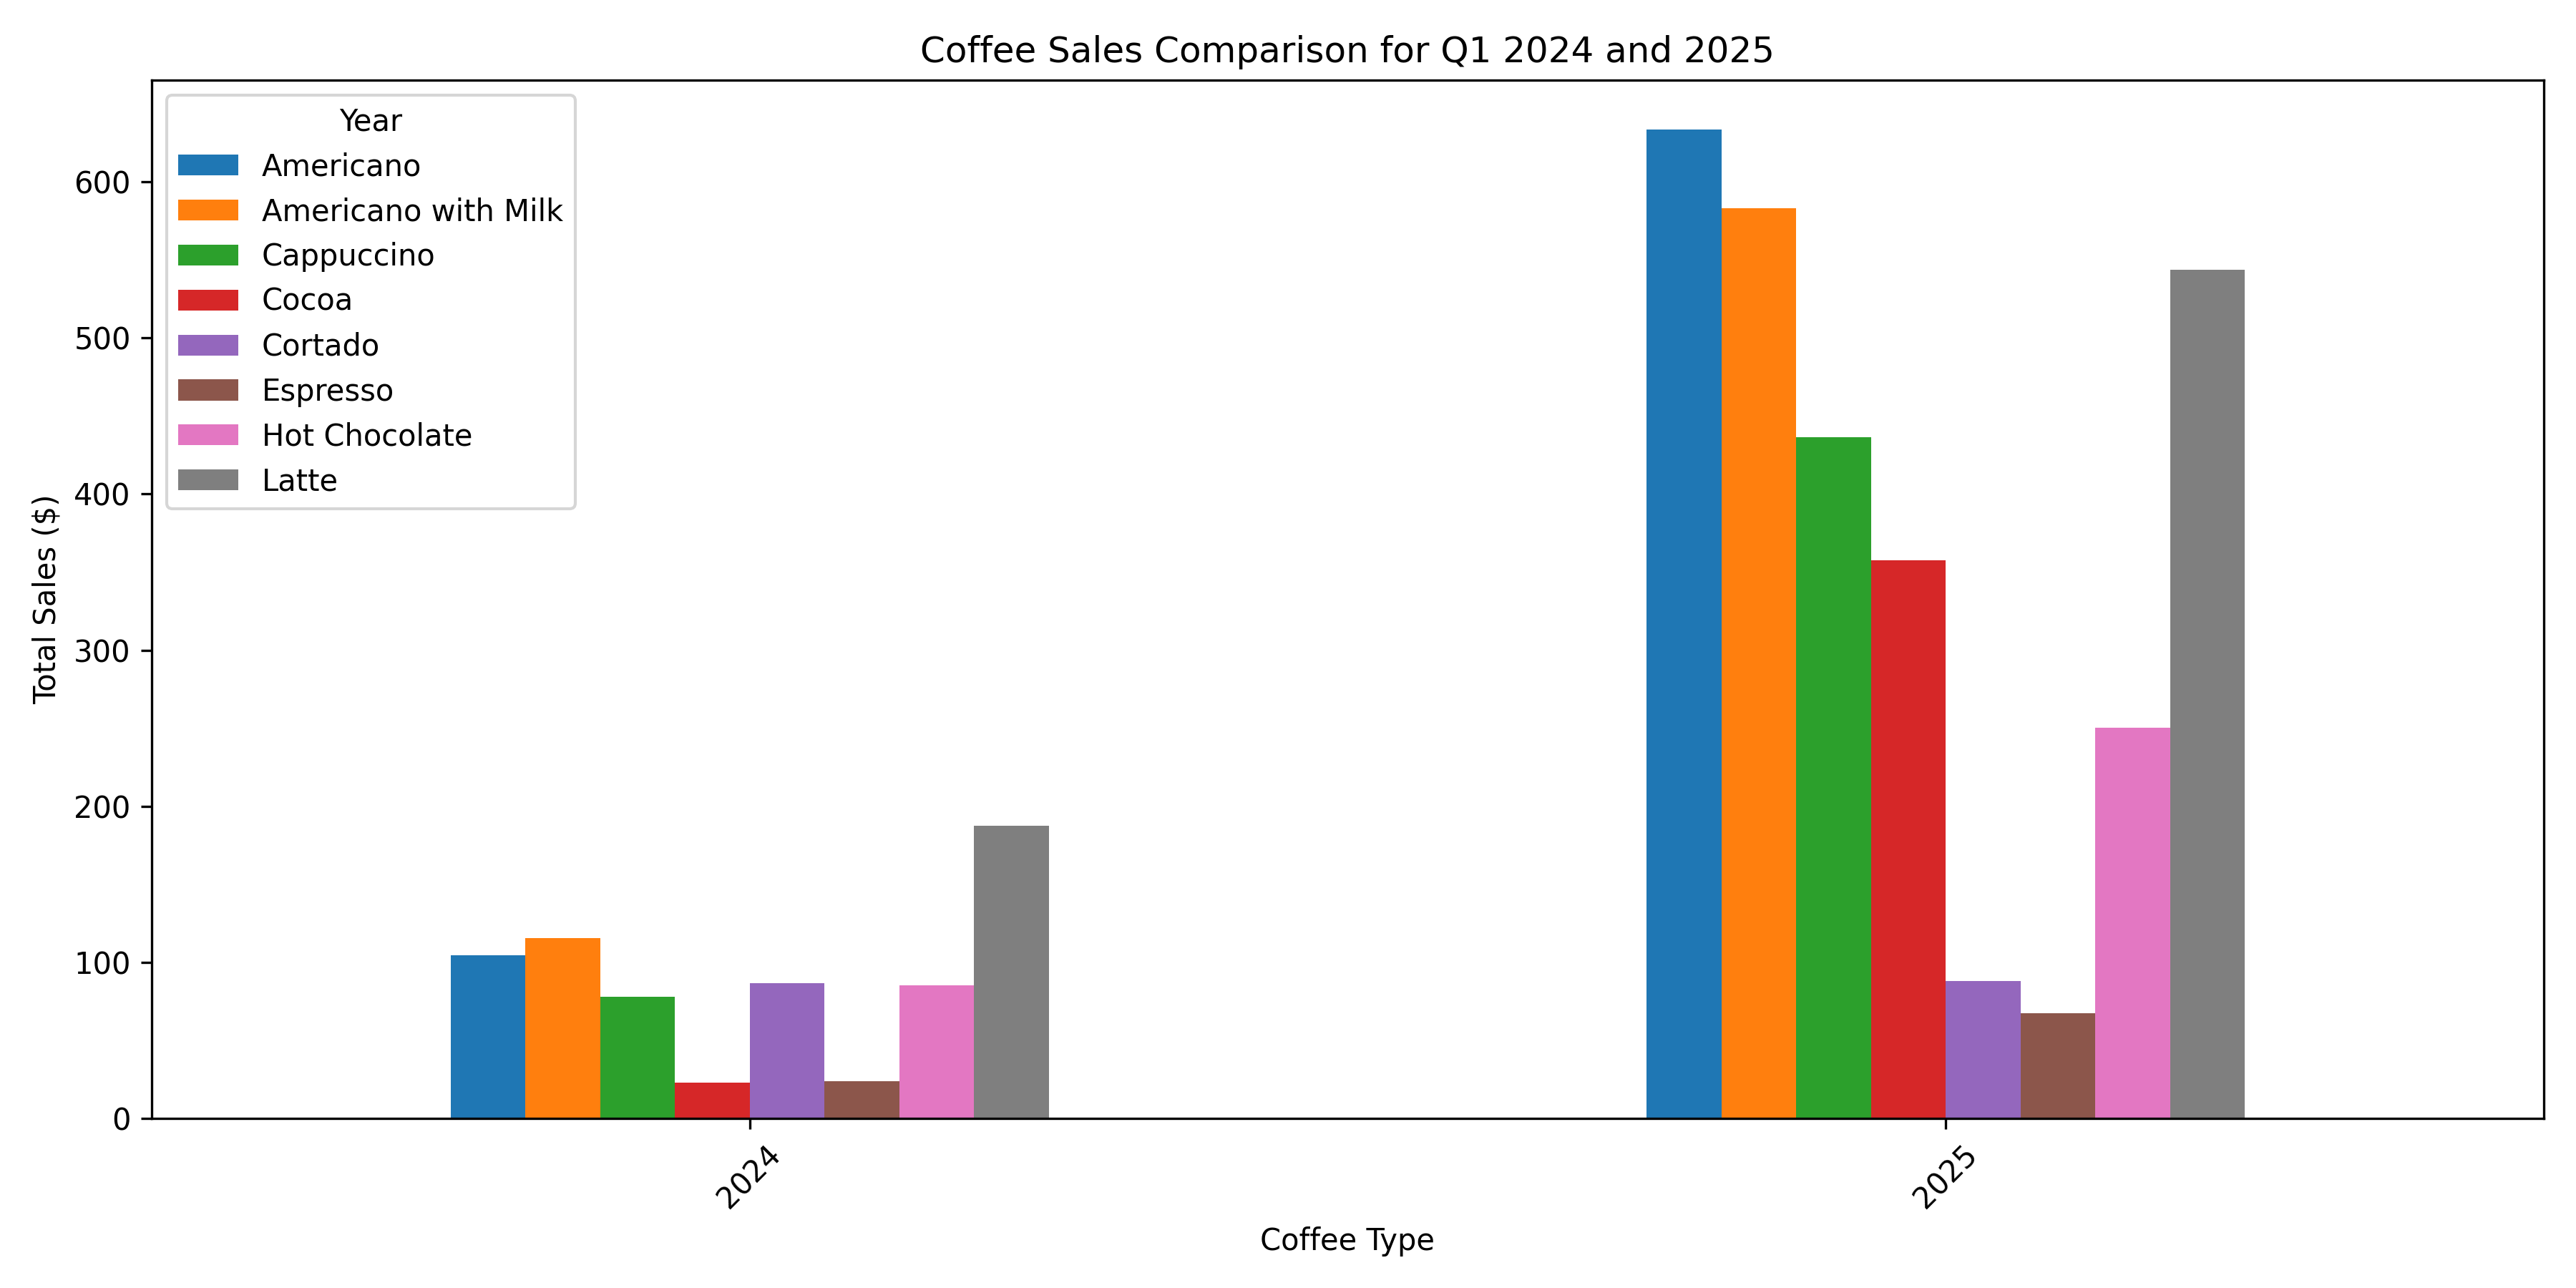

In [ ]:
# 提取 <execute_python> 标签内的代码
match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v1)
if match:
    initial_code = match.group(1).strip()
    utils.print_html(initial_code, title="待执行的提取代码")
    exec_globals = {"df": df}
    exec(initial_code, exec_globals)

# 若执行成功，chart_v1.png 已生成，在此展示
utils.print_html(
    content="chart_v1.png",
    title="生成图表（V1）",
    is_image=True
)

若生成图表出现报错，是LLM生成的代码存在问题，可重新运行3.1中的generate_chart_code()生成代码。

### 3.3 步骤 3 — 反思输出

本步骤模拟人类审查初版图表：找出优点、不足和可改进点。

流程：

1. **将图表提供给 LLM**：把生成的图表（chart_v1.png）传给支持视觉的 LLM
2. **视觉分析**：LLM 从清晰度、标签、准确度、可读性等角度审查
3. **生成反馈**：LLM 提出改进建议（例如修正坐标轴、更换图表类型、改进配色、补充图例）

这样形成一个**智能反馈循环**：图表不会被一次性生成后结束，而是经过主动审查，为更优的 V2 做准备。

In [ ]:
def reflect_on_image_and_regenerate(
    chart_path: str,
    instruction: str,
    model_name: str,
    out_path_v2: str,
    code_v1: str,
) -> tuple[str, str]:
    """
    根据图表图片和原代码进行反思，返回反馈和改进后的代码。
    使用 OpenRouter 的统一视觉接口。
    返回 (feedback, refined_code_with_tags)。
    """
    media_type, b64 = utils.encode_image_b64(chart_path)

    prompt = f"""
    你是一位数据可视化专家。
    任务：对照用户需求，对附件中的图表和原始代码进行 critique，然后返回改进后的 matplotlib 代码。

    原始代码（供参考）：
    {code_v1}

    请严格按以下格式输出：
    1) 第一行：仅包含 "feedback" 字段的有效 JSON 对象。
    例如：{{"feedback": "图例不清晰，坐标轴标签有重叠。"}}

    2) 换行后，仅输出改进后的 Python 代码，包裹在：
    <execute_python>
    ...
    </execute_python>

    3) 代码中导入所有必要的库，不要假设继承自原始代码。

    硬性约束：
    - 不要使用 Markdown、反引号或 JSON/标签以外的额外说明。
    - 仅使用 pandas/matplotlib（不要 seaborn）。
    - 假设 df 已存在，不要从文件读取。
    - 保存到 '{out_path_v2}'，dpi=300。
    - 结尾必须调用 plt.close()（不要 plt.show()）。
    - 包含所有必要的 import。

    df 可用列：
    - date (M/D/YY), time (HH:MM), cash_type, card, price, coffee_name
    - quarter (1-4), month (1-12), year (YYYY)

    用户需求：
    {instruction}
    """

    content = utils.image_openrouter_call(model_name, prompt, media_type, b64)

    lines = content.strip().splitlines()
    json_line = lines[0].strip() if lines else ""

    try:
        obj = json.loads(json_line)
    except Exception as e:
        m_json = re.search(r"\{.*?\}", content, flags=re.DOTALL)
        if m_json:
            try:
                obj = json.loads(m_json.group(0))
            except Exception:
                obj = {"feedback": f"解析 JSON 失败: {e}"}
        else:
            obj = {"feedback": f"未找到 JSON: {e}"}

    m_code = re.search(r"<execute_python>([\s\S]*?)</execute_python>", content)
    refined_code_body = m_code.group(1).strip() if m_code else ""
    refined_code = utils.ensure_execute_python_tags(refined_code_body)

    feedback = str(obj.get("feedback", "")).strip()
    return feedback, refined_code

模型被要求以 **JSON 格式** 返回反馈：

- **JSON**：轻量级键值对格式，便于程序解析 LLM 输出
- 此处需要 **`feedback`** 字段：对当前图表的简短评价
- 改进后的代码包裹在 `<execute_python>` 标签中

提示词中还包括**约束部分**（如只使用 matplotlib、保存到指定路径等），让模型输出更一致、可执行。

### 3.4 步骤 4 — 生成并执行改进版（V2）

最后一步：调用反思函数，得到 LLM 的**反馈**和**改进代码**，然后执行代码生成 V2 图表。

In [ ]:
feedback, code_v2 = reflect_on_image_and_regenerate(
    chart_path="chart_v1.png",
    instruction="使用 coffee_sales.csv 创建 2024 年和 2025 年 Q1 咖啡销售的对比图。",
    model_name="openai/gpt-4o-mini",  # 需支持视觉的模型
    out_path_v2="chart_v2.png",
    code_v1=code_v1,
)

utils.print_html(feedback, title="对 V1 图表的反馈")
utils.print_html(code_v2, title="改进后的代码（V2）")

接下来执行改进后的代码，提取 `<execute_python>` 内的代码、运行，并展示 `chart_v2.png`。


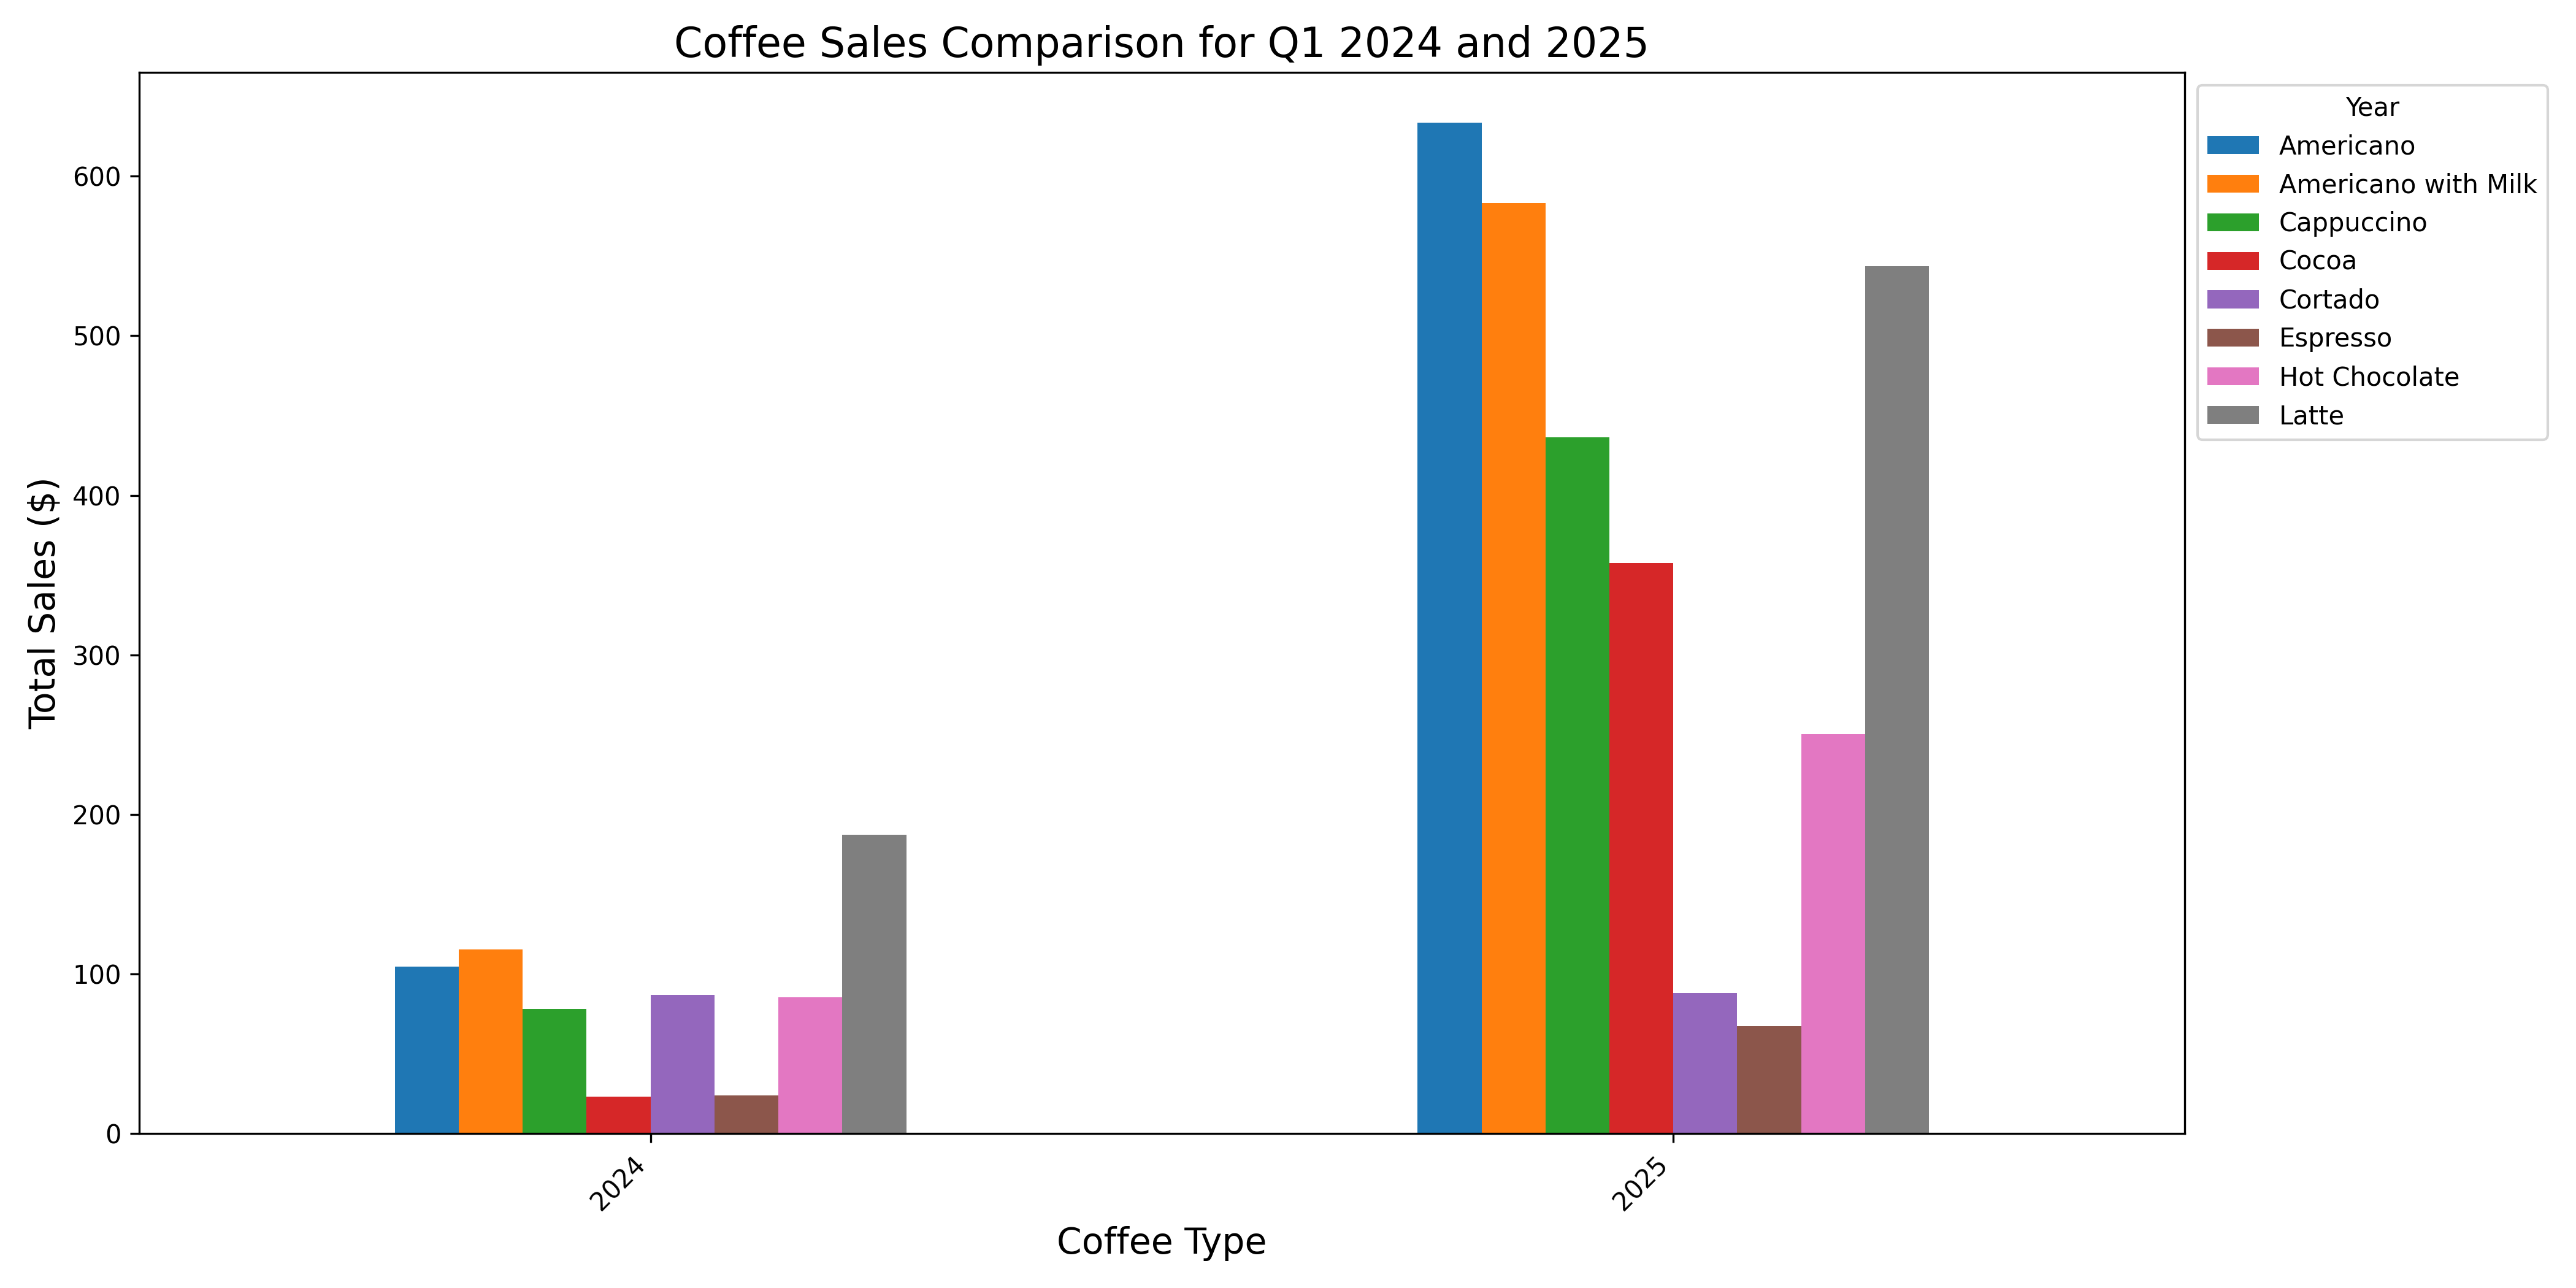

In [ ]:
match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v2)
if match:
    reflected_code = match.group(1).strip()
    exec_globals = {"df": df}
    exec(reflected_code, exec_globals)

utils.print_html(
    content="chart_v2.png",
    title="改进后的图表（V2）",
    is_image=True
)

### 4. 整合为端到端工作流

将以上步骤整合为单一的 `run_workflow` 函数，实现完整自动化流程：

1. **加载数据** — `utils.load_and_prepare_data(...)`
2. **生成 V1 代码** — `generate_chart_code(...)`
3. **执行 V1** — 提取并运行代码，生成第一版图表
4. **反思并 refine** — `reflect_on_image_and_regenerate(...)` 返回反馈和 V2 代码
5. **执行 V2** — 运行改进代码，生成最终图表

**参数说明**：
- `dataset_path`：CSV 文件路径（相对于项目根目录）
- `user_instructions`：图表需求描述
- `generation_model`：用于生成初版代码的 OpenRouter 模型
- `reflection_model`：用于看图反思的 OpenRouter 模型（需支持视觉）
- `image_basename`：图表文件名前缀

In [ ]:
def run_workflow(
    dataset_path: str,
    user_instructions: str,
    generation_model: str,
    reflection_model: str,
    image_basename: str = "chart",
):
    """
    端到端流水线：
    1) 加载数据
    2) 生成 V1 代码
    3) 执行 V1 → 生成 chart_v1.png
    4) 反思 V1 → 得到反馈和 V2 代码
    5) 执行 V2 → 生成 chart_v2.png

    返回包含 codes、feedback、图片路径的字典。
    """
    df = utils.load_and_prepare_data(dataset_path)
    utils.print_html(df.sample(n=5), title="数据集随机抽样")

    out_v1 = f"{image_basename}_v1.png"
    out_v2 = f"{image_basename}_v2.png"

    utils.print_html("步骤 1：生成图表代码（V1）… 📈", title="进度")
    code_v1 = generate_chart_code(
        instruction=user_instructions,
        model=generation_model,
        out_path_v1=out_v1,
    )
    utils.print_html(code_v1, title="LLM 第一版代码（V1）")

    utils.print_html("步骤 2：执行 V1 代码… 💻", title="进度")
    match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v1)
    if match:
        exec(match.group(1).strip(), {"df": df})
    utils.print_html(out_v1, is_image=True, title="生成图表（V1）")

    utils.print_html("步骤 3：反思 V1 并生成改进代码… 🔁", title="进度")
    feedback, code_v2 = reflect_on_image_and_regenerate(
        chart_path=out_v1,
        instruction=user_instructions,
        model_name=reflection_model,
        out_path_v2=out_v2,
        code_v1=code_v1,
    )
    utils.print_html(feedback, title="反思反馈")
    utils.print_html(code_v2, title="LLM 改进代码（V2）")

    utils.print_html("步骤 4：执行 V2 代码… 🖼️", title="进度")
    match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v2)
    if match:
        exec(match.group(1).strip(), {"df": df})
    utils.print_html(out_v2, is_image=True, title="改进图表（V2）")

    return {
        "code_v1": code_v1,
        "chart_v1": out_v1,
        "feedback": feedback,
        "code_v2": code_v2,
        "chart_v2": out_v2,
    }

### 4.2 运行完整工作流

使用课程中的示例需求运行完整工作流。你可以：

- 修改 `user_instructions` 尝试不同图表需求
- 修改 `image_basename` 区分多次运行结果
- 更换 `generation_model` 和 `reflection_model` 探索不同模型效果

**OpenRouter 常用模型示例**：
- `openai/gpt-4o-mini`：速度较快，适合代码生成
- `openai/gpt-4o`：更强推理能力，适合反思
- `anthropic/claude-3-haiku`：轻量、快速
- `anthropic/claude-3-5-sonnet`：能力强，适合复杂反思

date,time,cash_type,card,price,coffee_name,quarter,month,year
2024-06-03,11:38,card,ANON-0000-0000-0024,3.282,Americano with Milk,2,6,2024
2024-09-05,07:57,card,ANON-0000-0000-0582,3.282,Latte,3,9,2024
2025-03-22,08:23,card,ANON-0000-0000-1274,3.086,Americano with Milk,1,3,2025
2024-09-28,08:30,card,ANON-0000-0000-0445,3.576,Latte,3,9,2024
2025-03-04,07:23,card,ANON-0000-0000-1187,3.086,Americano with Milk,1,3,2025



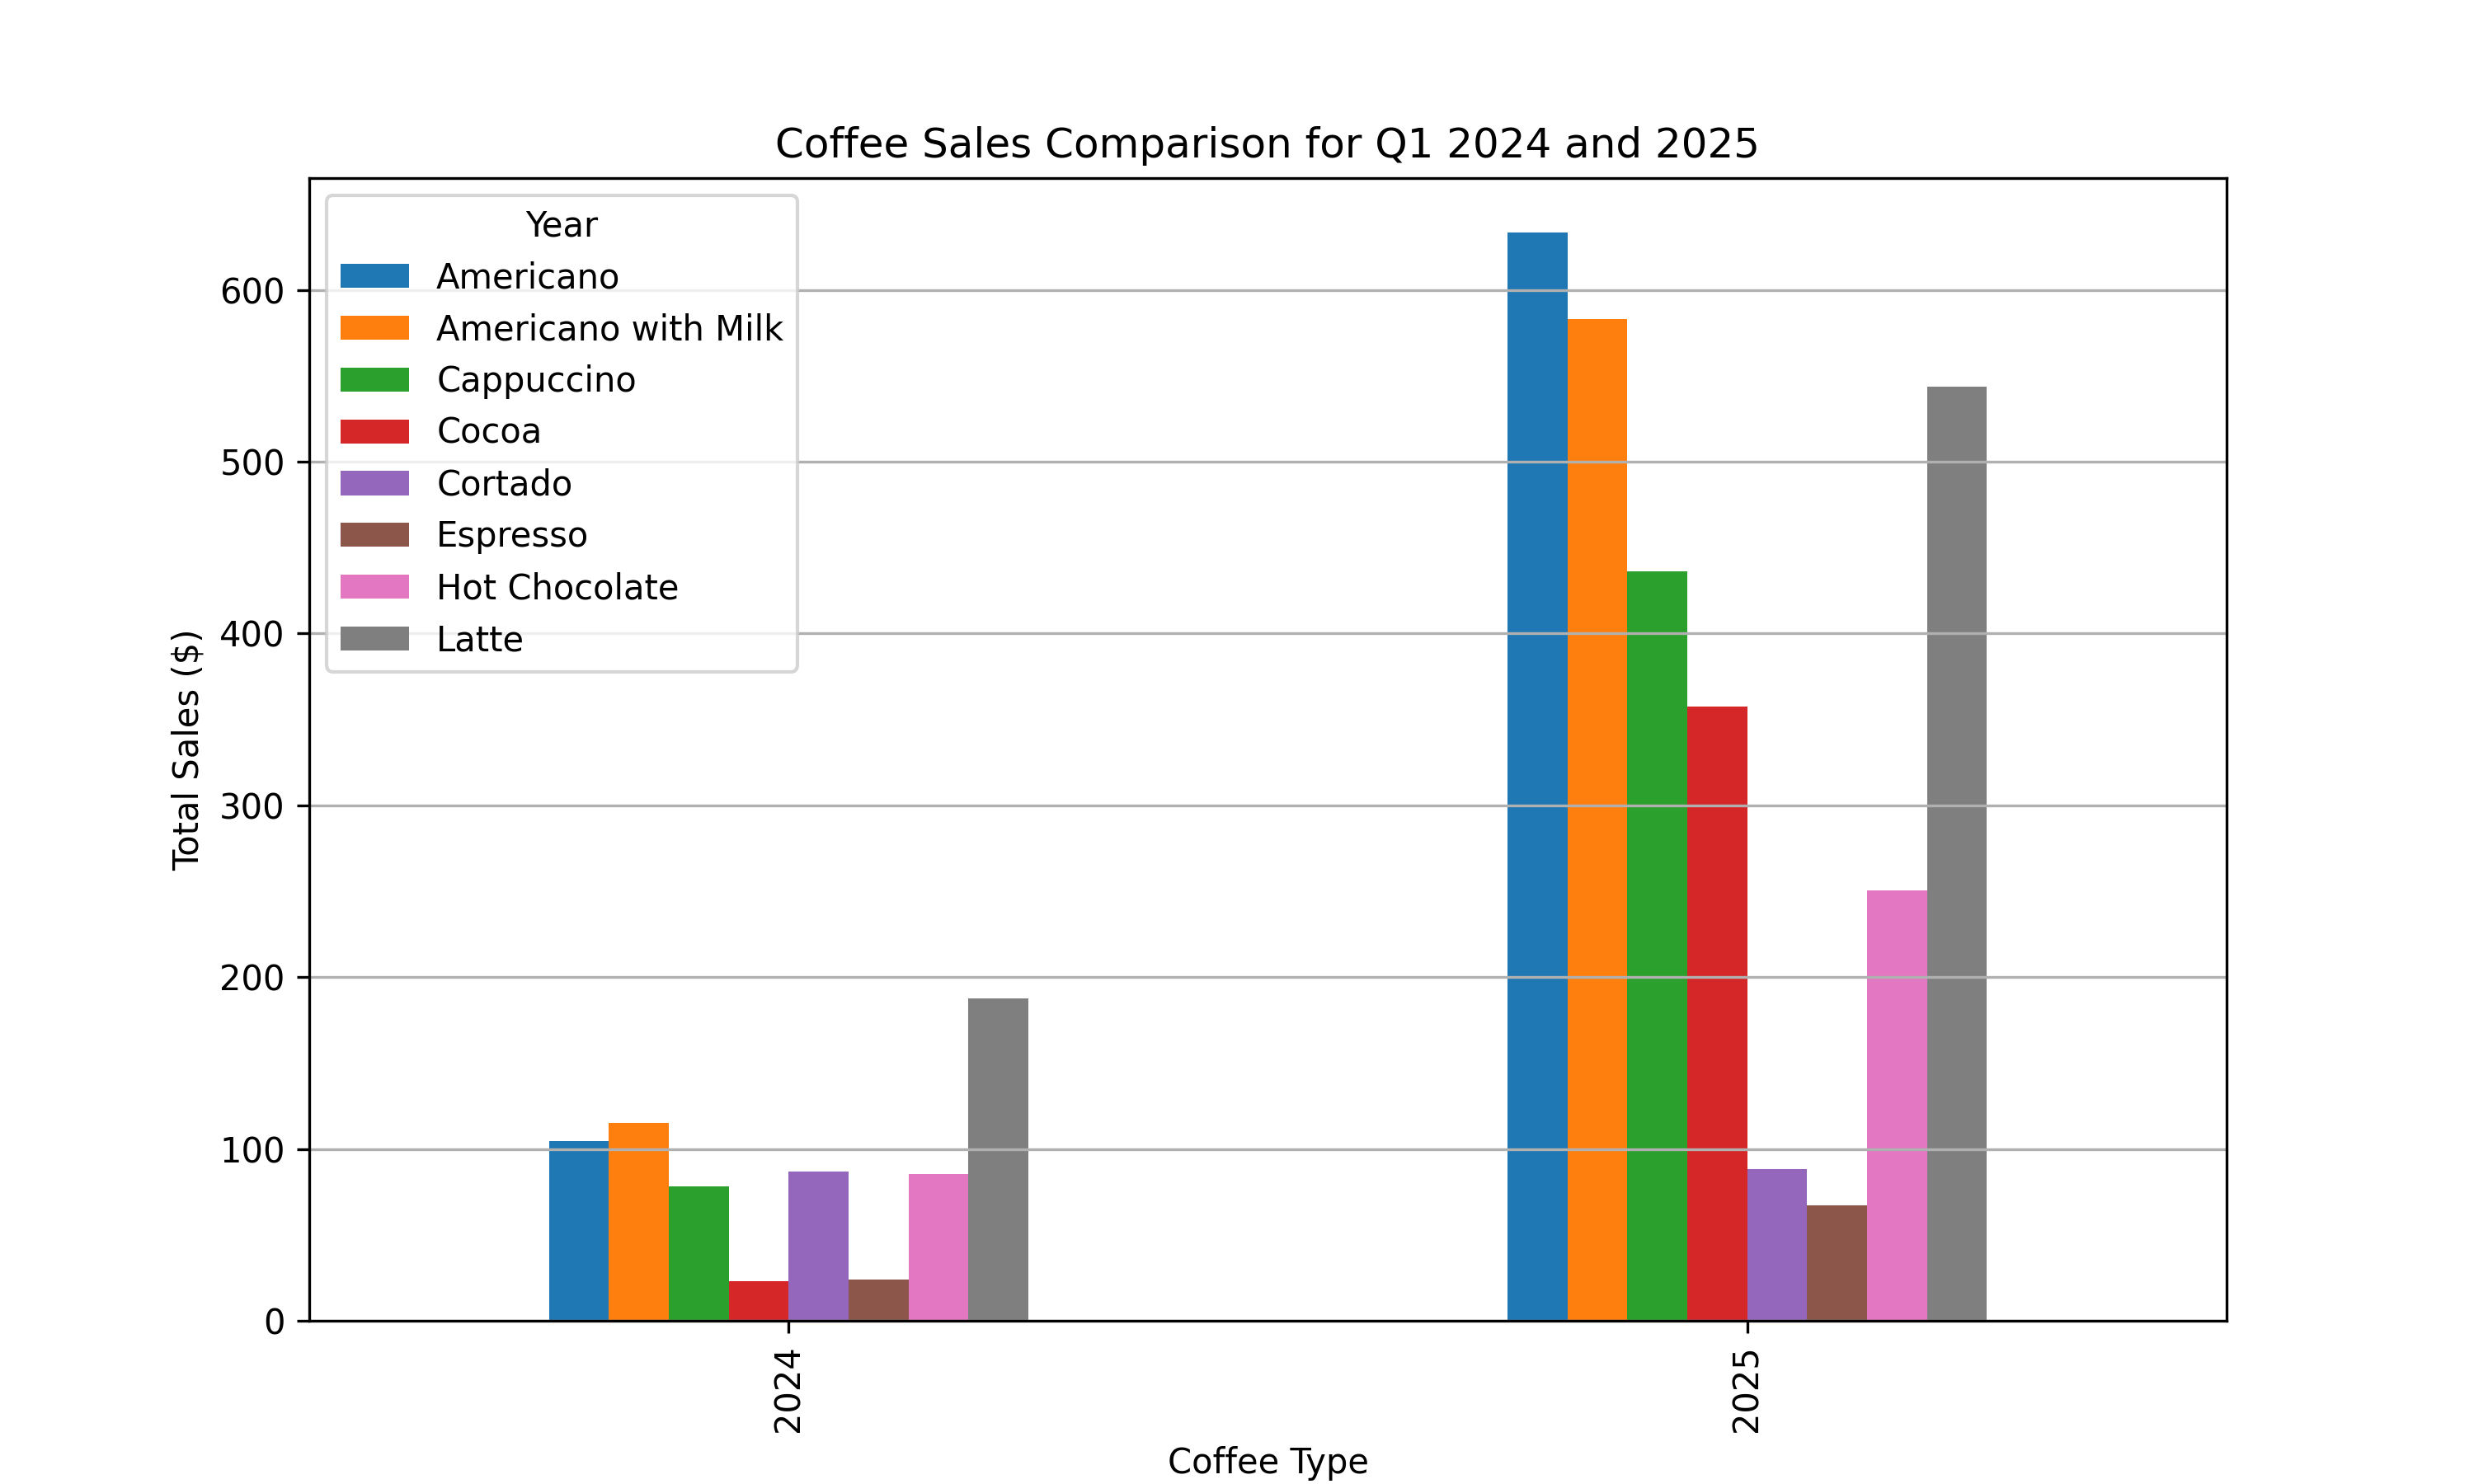


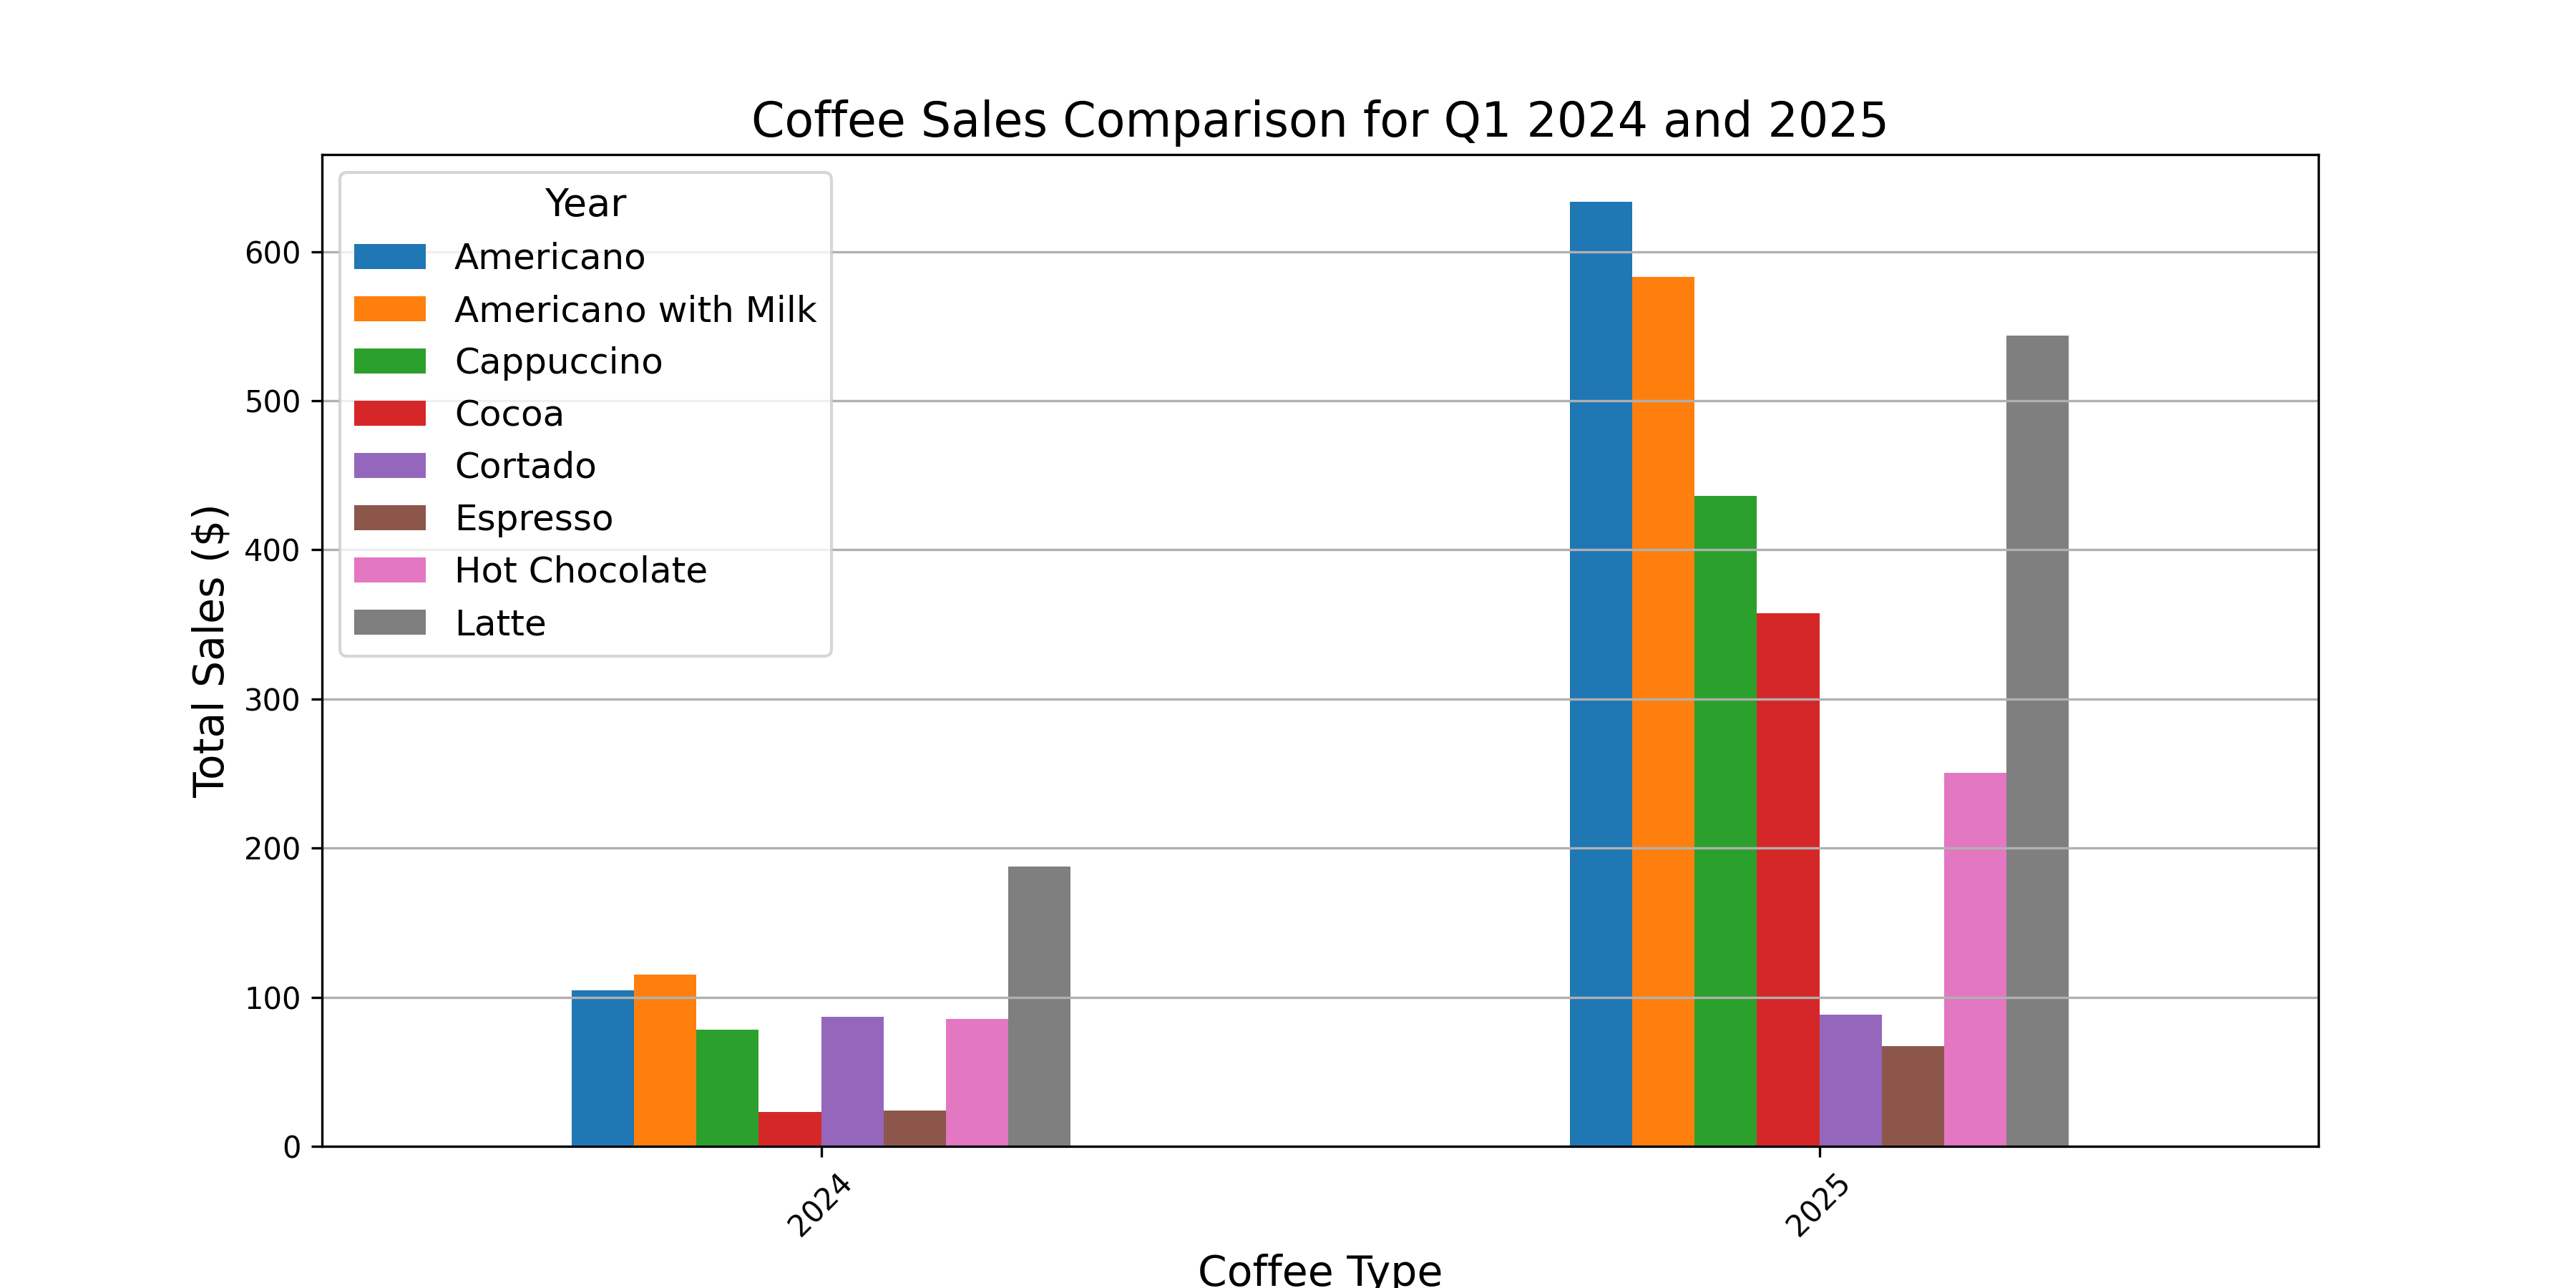

In [ ]:
user_instructions = "使用 coffee_sales.csv 创建 2024 年和 2025 年 Q1 咖啡销售的对比图。"
generation_model = "openai/gpt-4o-mini"
reflection_model = "openai/gpt-4o-mini"  # 需支持视觉
image_basename = "drink_sales"

_ = run_workflow(
    dataset_path="coffee_sales.csv",
    user_instructions=user_instructions,
    generation_model=generation_model,
    reflection_model=reflection_model,
    image_basename=image_basename,
)

## 5. 动手练习：尝试分析咖啡种类和销量的关系 (20%)

请在下方实现代码，调用LLM通过画图实现对不同种类咖啡销量的分析，找出最受欢迎的咖啡。

**预期效果：** 画出图表显示咖啡种类和销量之间的关系

In [ ]:
code_v1 = generate_chart_code(
    instruction="使用 coffee_sales.csv 画出图表显示咖啡种类和销量之间的关系，找出最受欢迎的咖啡",
    model="openai/gpt-4o-mini",
    out_path_v1="chart_v1.png"
)

utils.print_html(code_v1, title="LLM 生成的第一版代码")


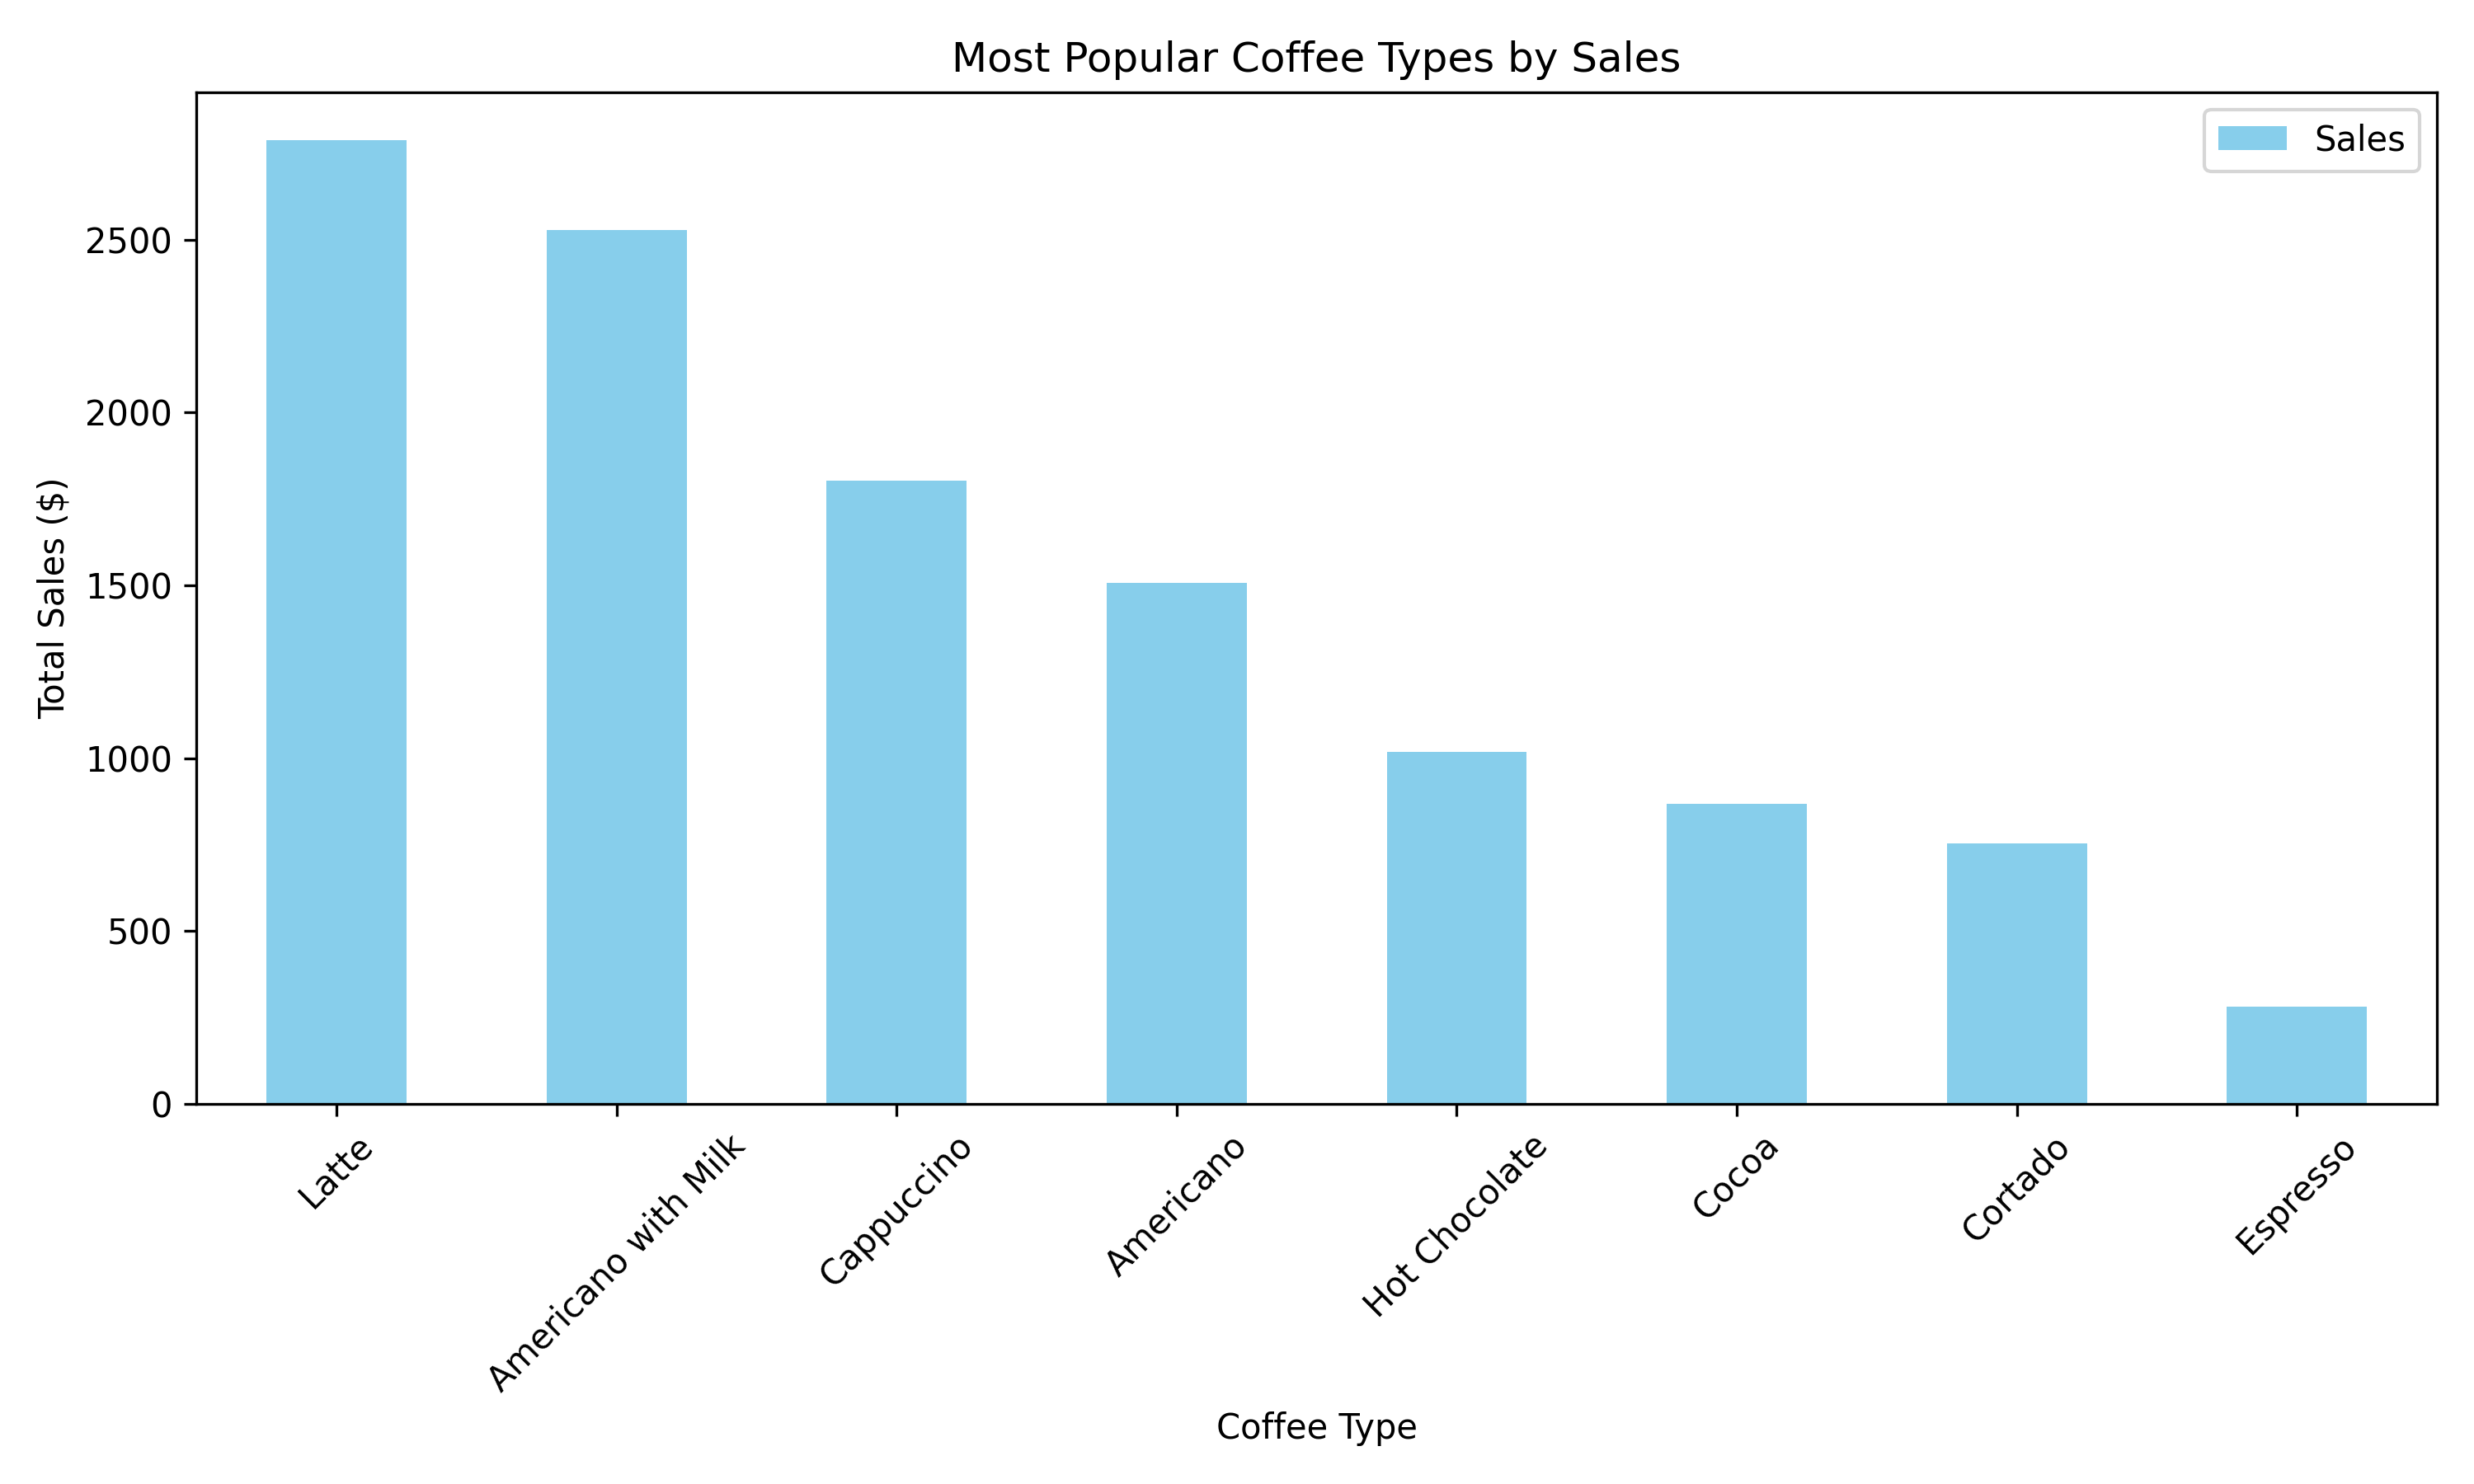

In [ ]:
match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v1)
if match:
    initial_code = match.group(1).strip()
    utils.print_html(initial_code, title="待执行的提取代码")
    exec_globals = {"df": df}
    exec(initial_code, exec_globals)

utils.print_html(
    content="chart_v1.png",
    title="生成图表（V1）",
    is_image=True
)

In [ ]:
feedback, code_v2 = reflect_on_image_and_regenerate(
    chart_path="chart_v1.png",
    instruction="使用 coffee_sales.csv 画出图表显示咖啡种类和销量之间的关系，找出最受欢迎的咖啡",
    model_name="openai/gpt-4o-mini",
    out_path_v2="chart_v2.png",
    code_v1=code_v1,
)

utils.print_html(feedback, title="对 V1 图表的反馈")
utils.print_html(code_v2, title="改进后的代码（V2）")


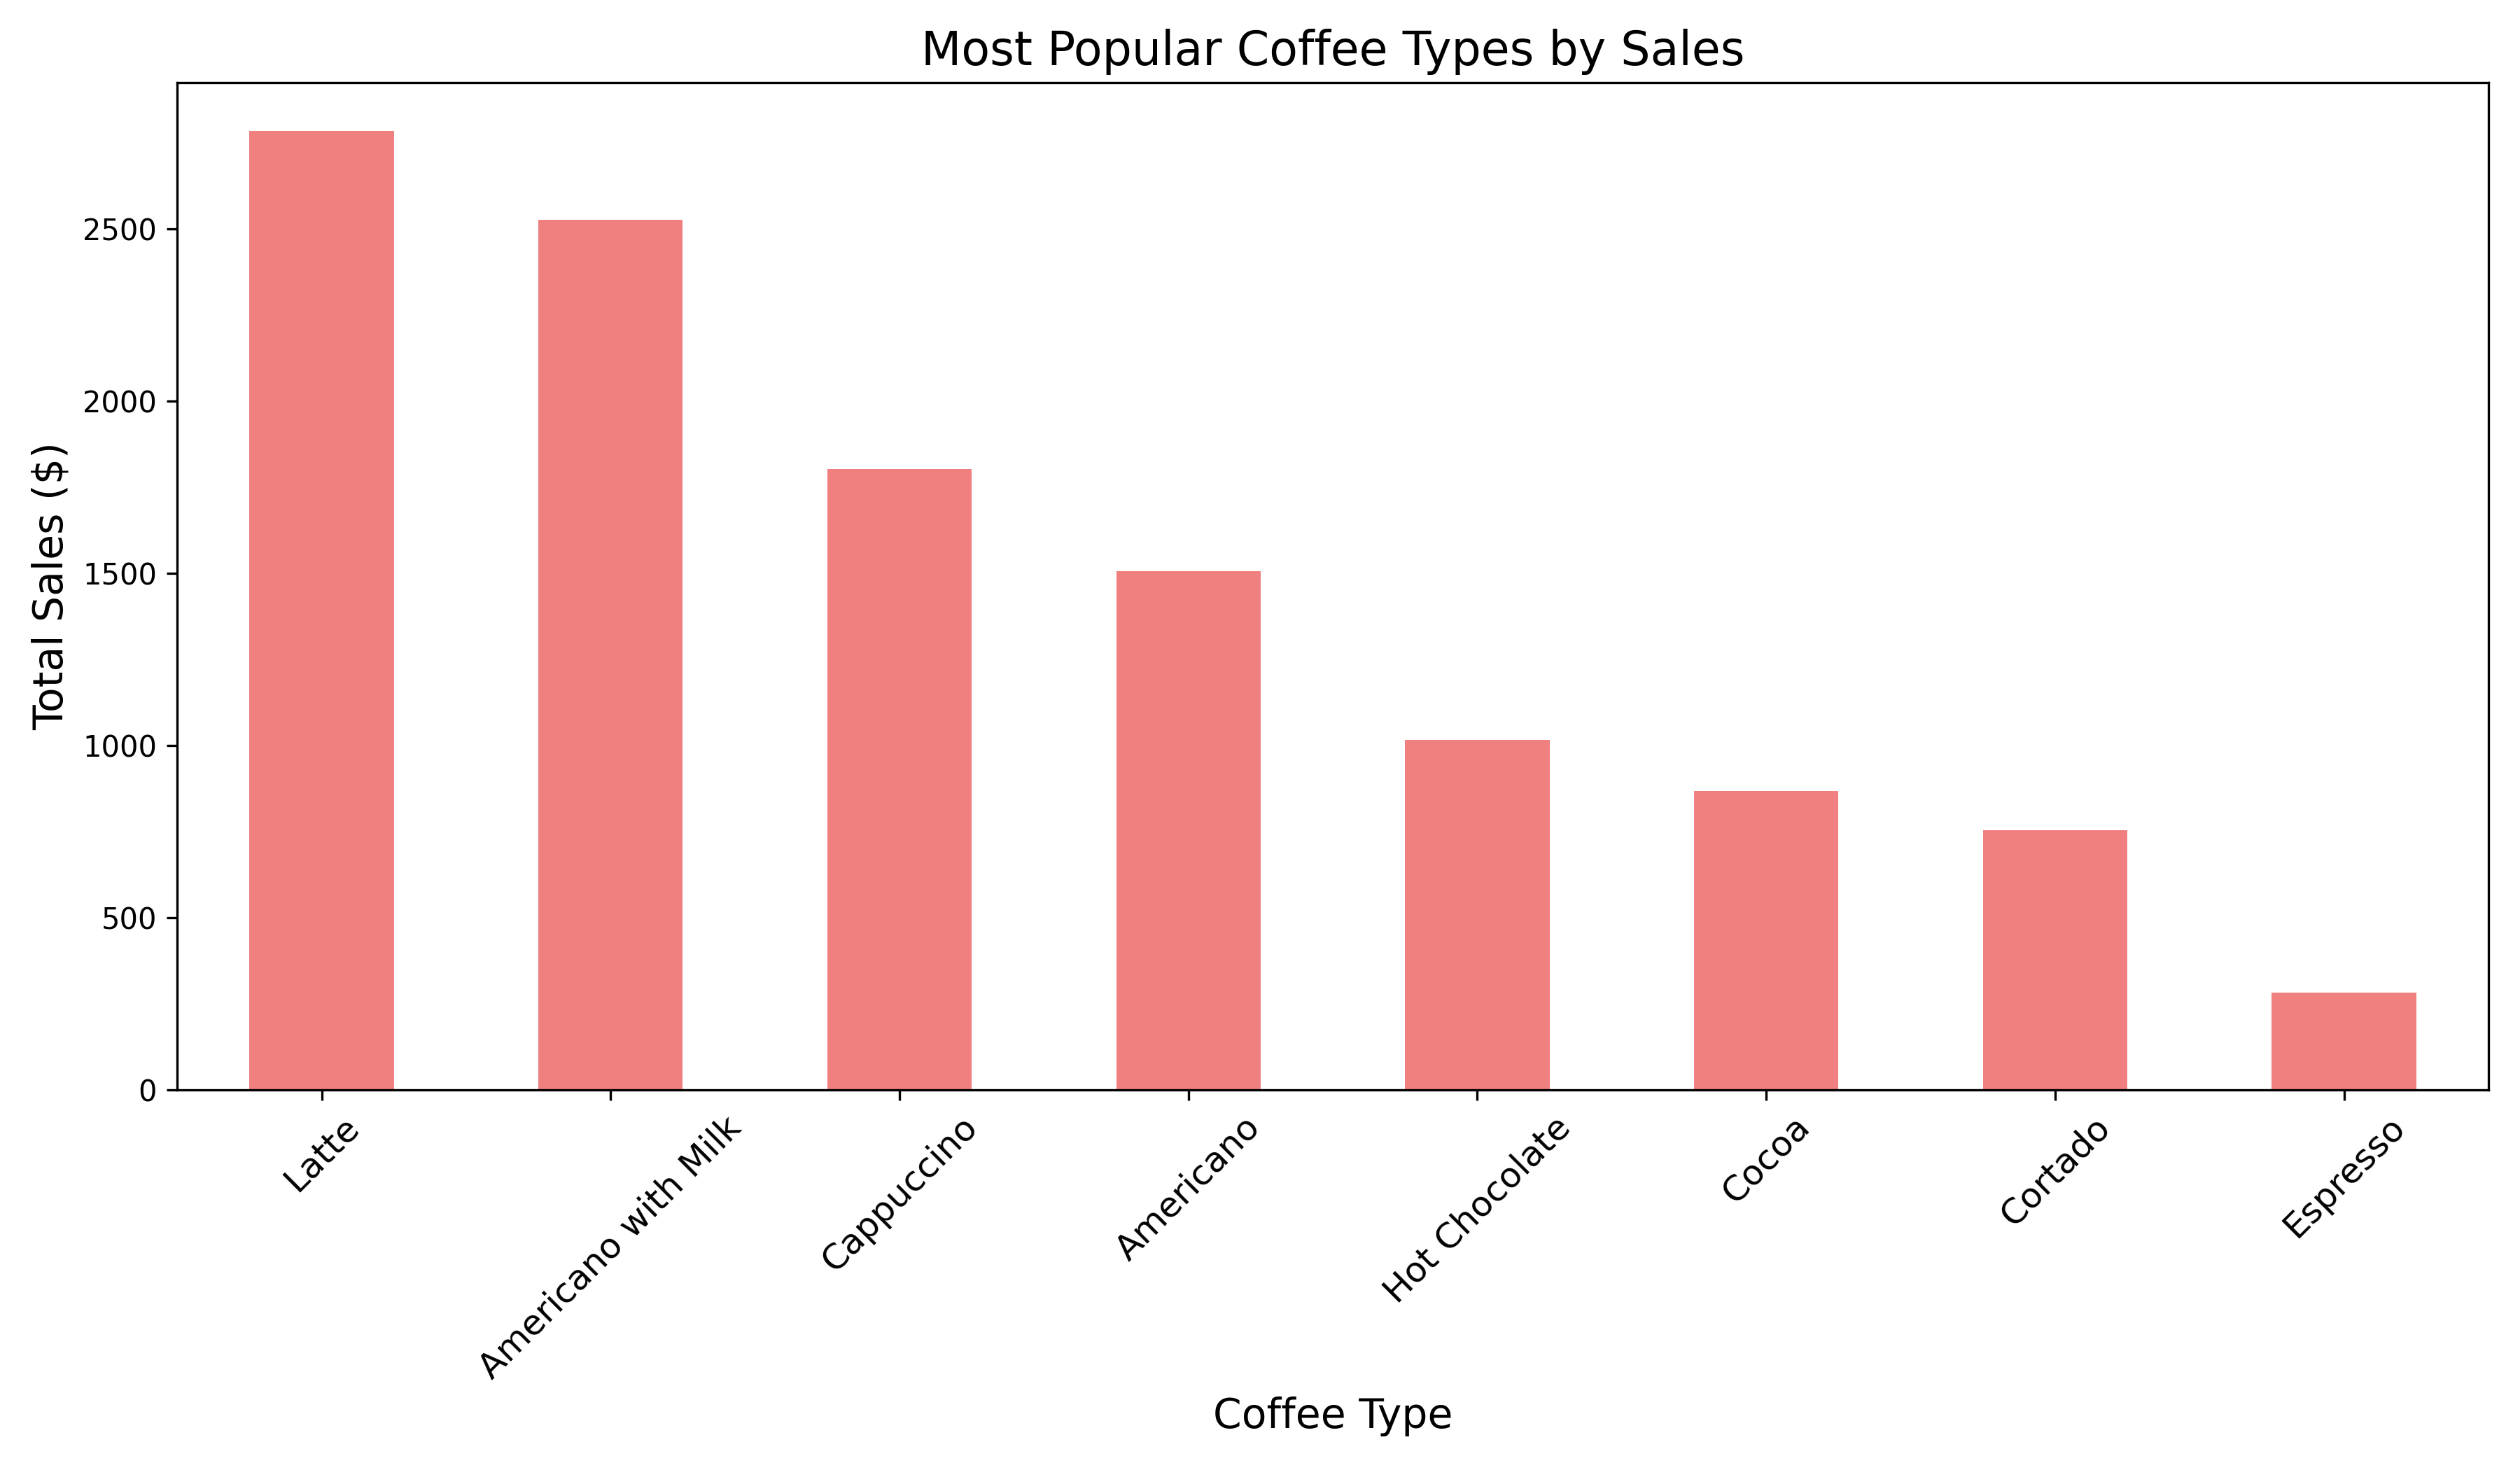

In [ ]:
match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v2)
if match:
    reflected_code = match.group(1).strip()
    exec_globals = {"df": df}
    exec(reflected_code, exec_globals)

utils.print_html(
    content="chart_v2.png",
    title="改进后的图表（V2）",
    is_image=True
)

date,time,cash_type,card,price,coffee_name,quarter,month,year
2025-02-20,09:49,card,ANON-0000-0000-1198,2.596,Americano,1,2,2025
2024-12-08,16:36,card,ANON-0000-0000-0976,3.086,Americano with Milk,4,12,2024
2024-07-30,12:01,card,ANON-0000-0000-0430,2.792,Americano with Milk,3,7,2024
2024-04-19,15:35,card,ANON-0000-0000-0124,3.870,Cappuccino,2,4,2024
2025-02-17,16:25,card,ANON-0000-0000-1223,2.596,Americano,1,2,2025



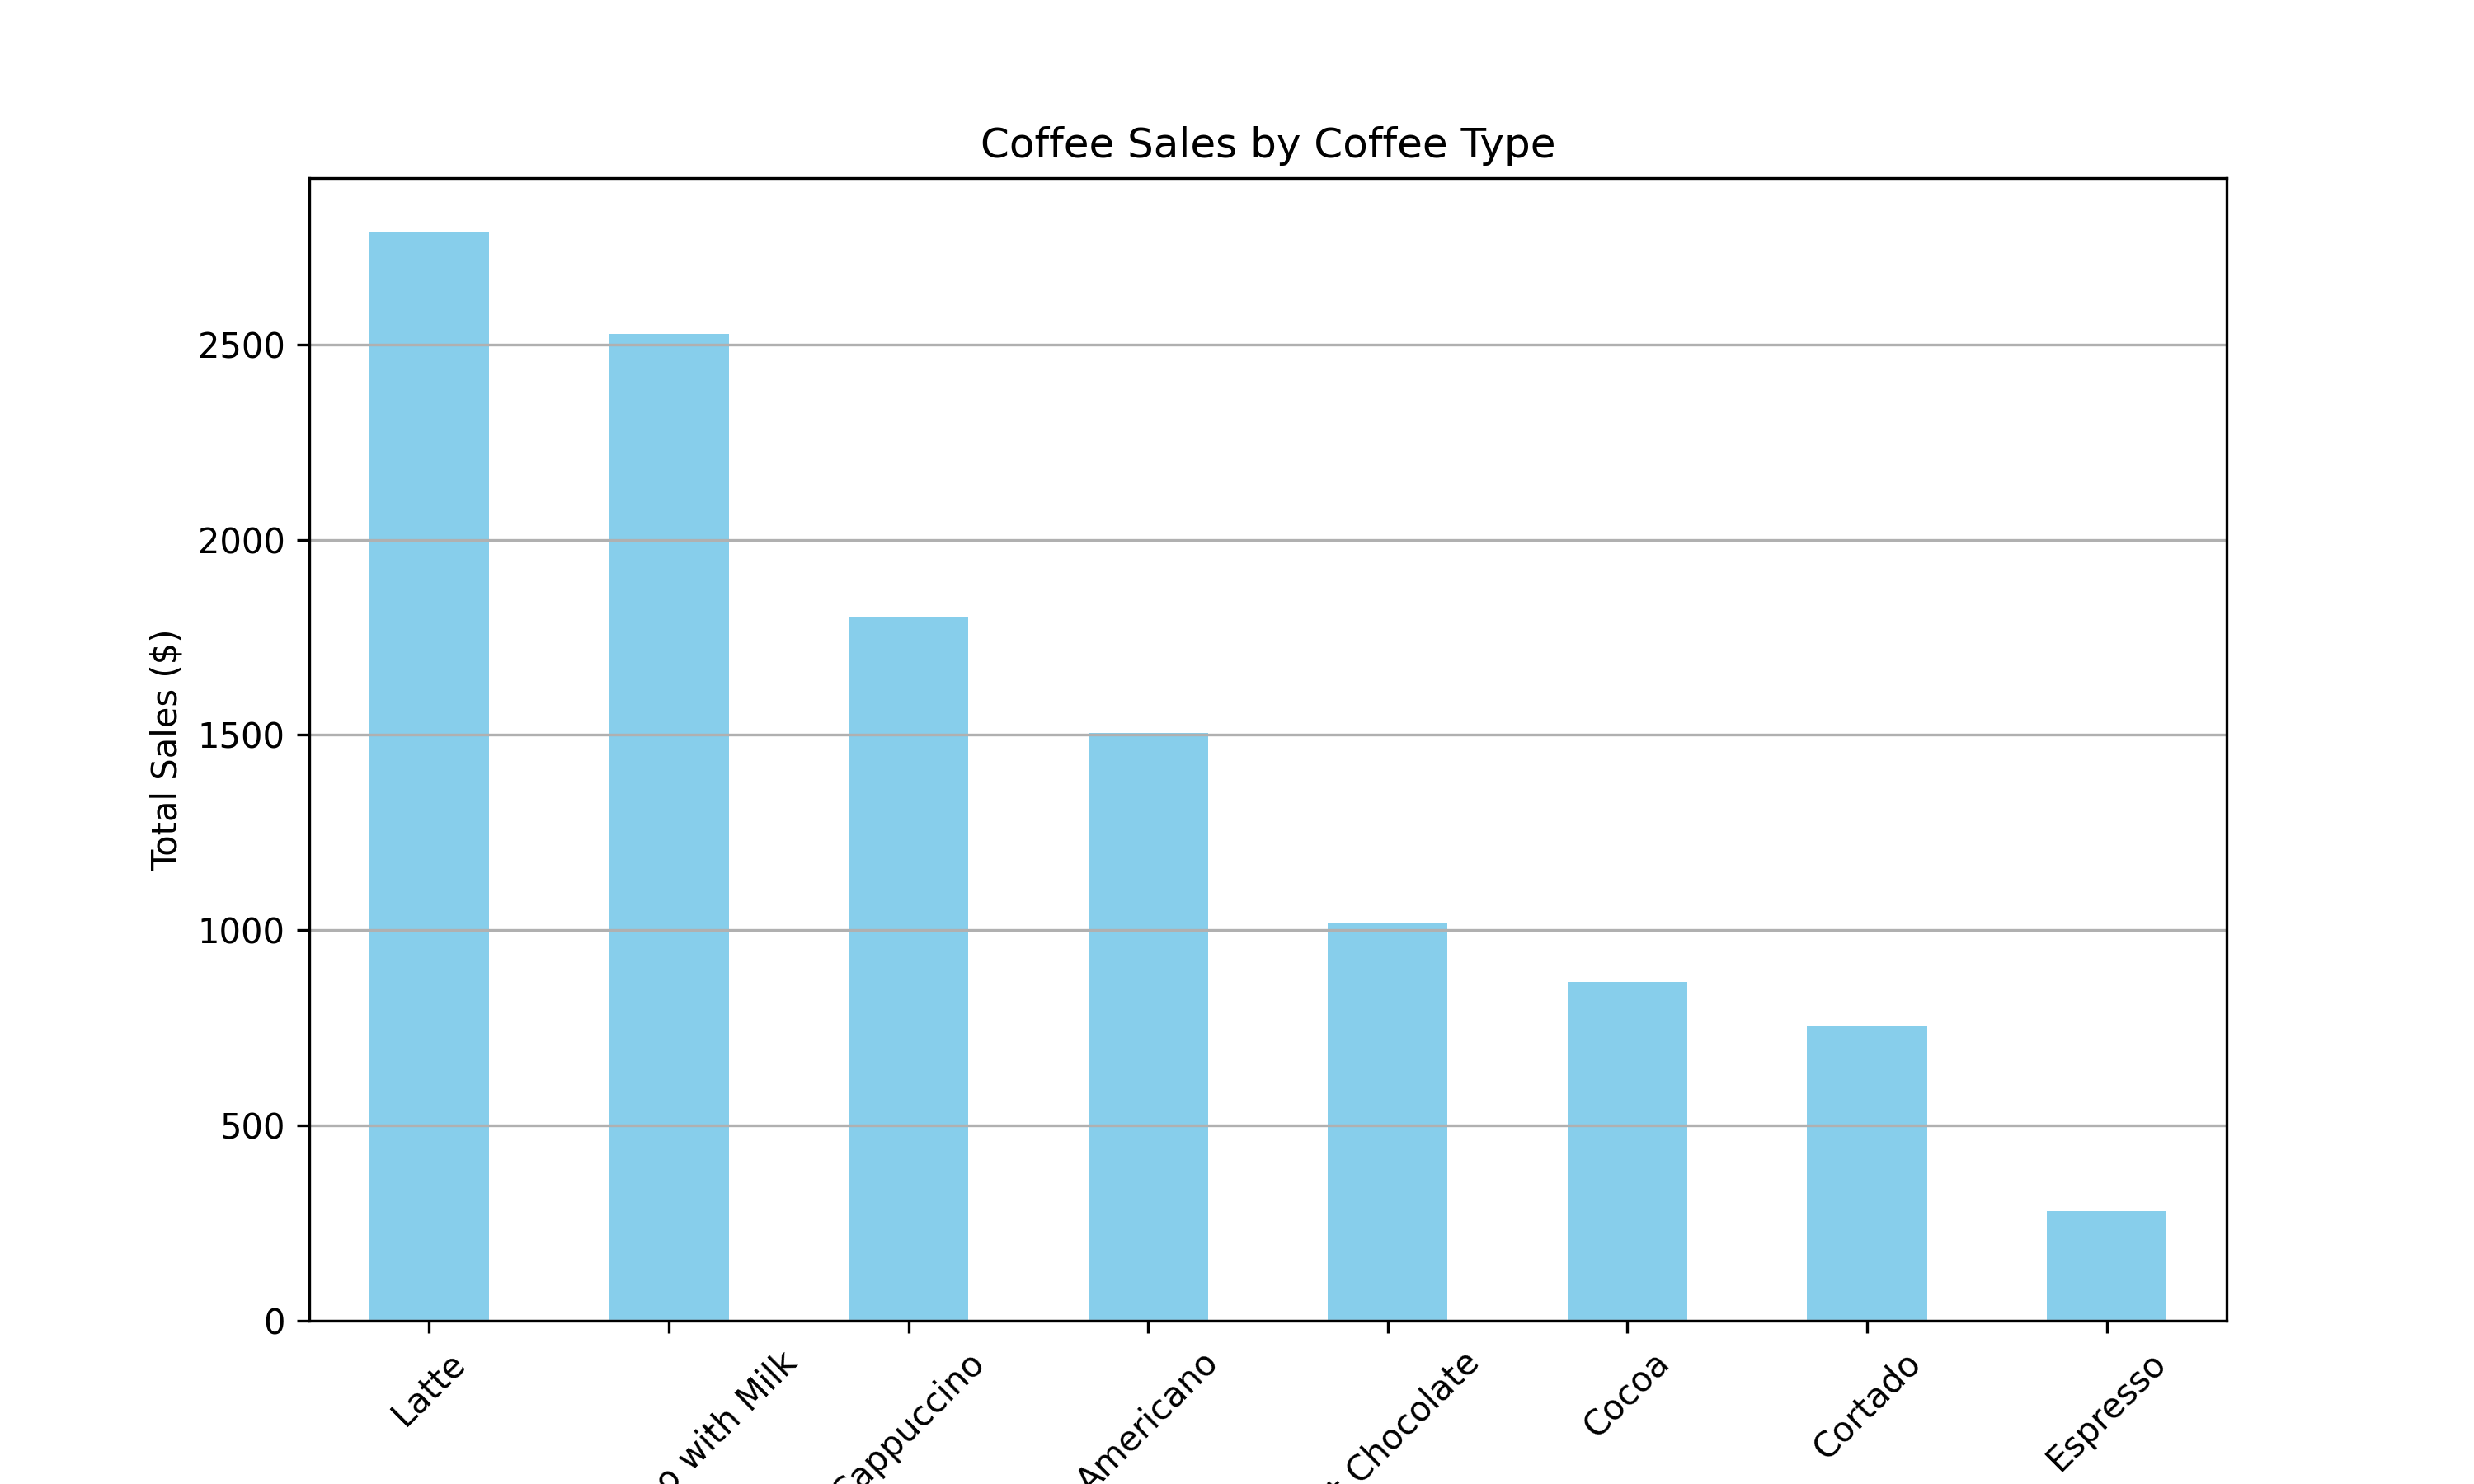


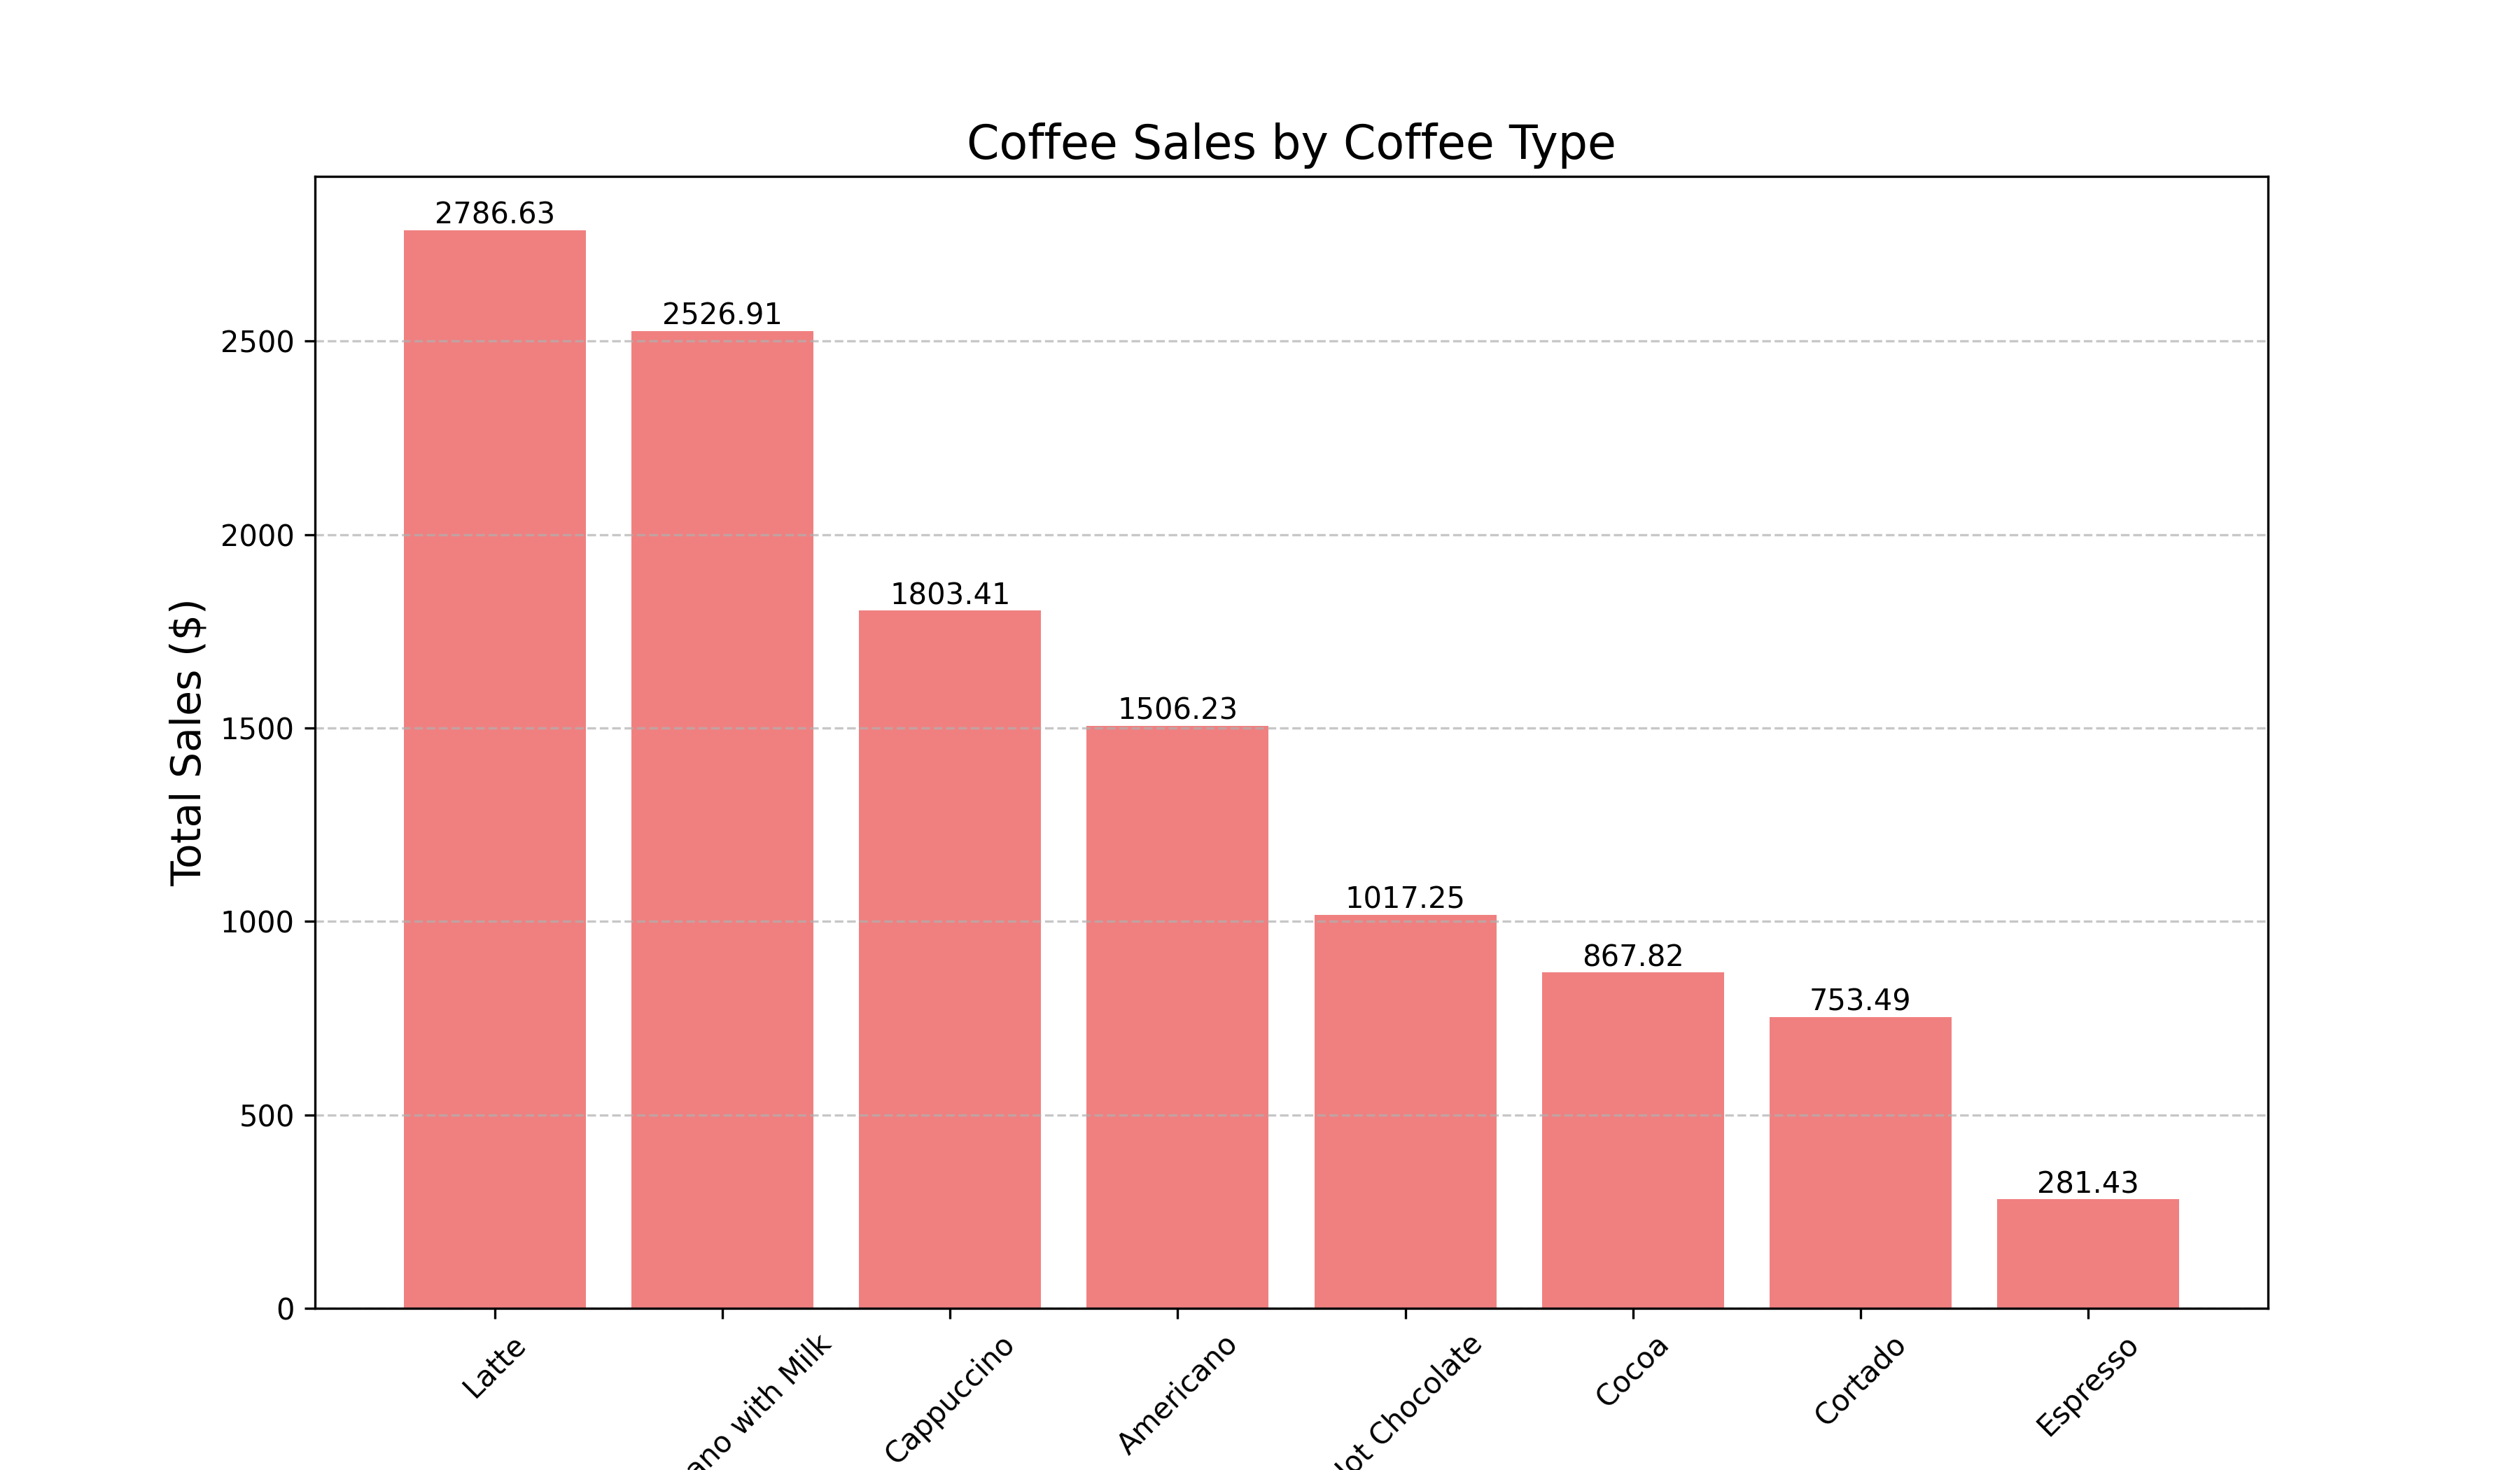

In [ ]:
user_instructions = "使用 coffee_sales.csv 画出图表，显示咖啡种类和销量之间的关系，并找出最受欢迎的咖啡"
generation_model = "openai/gpt-4o-mini"
reflection_model = "openai/gpt-4o-mini"  # 需支持视觉
image_basename = "drink_sales"

_ = run_workflow(
    dataset_path="coffee_sales.csv",
    user_instructions=user_instructions,
    generation_model=generation_model,
    reflection_model=reflection_model,
    image_basename=image_basename,
)

## 6. 总结

本实验你完成了：

* 生成初版图表（V1）
* 通过反思与改进得到更好的 V2
* 使用 OpenRouter 统一接口调用不同模型
* 实现从数据到可视化的端到端智能体流水线

**核心理念**：反思模式帮助你生成更清晰、准确、有效的可视化。

<div style="border:1px solid #22c55e; border-left:6px solid #16a34a; background:#dcfce7; border-radius:6px; padding:14px 16px; color:#064e3b; font-family:system-ui,-apple-system,Segoe UI,Roboto,sans-serif;">

🎉 **恭喜！**

你已完成了基于**反思模式**的智能体图表生成实验。你学会了如何生成图表、对输出进行反思，并自动得到改进版本。

掌握这些技能后，你可以设计更多智能体流水线，自动生成准确、可解释且高质量的数据可视化。🌟

</div>